# Understanding the Data

**H1:** What proportion of users are one-time buyers, and could this indicate potential dissatisfaction or low retention?

**H2:** Which product categories account for the largest share of total sales? (Pareto 80/20?)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

plt.style.use('ggplot')

PROJECT_ROOT = Path('/home/tomas/zrive-ds')
data_path = PROJECT_ROOT / 'data/raw'

In [3]:
orders = pd.read_parquet(f'{data_path}/orders.parquet')
inventory = pd.read_parquet(f'{data_path}/inventory.parquet')

print('orders:', orders.shape)
print('inventory:', inventory.shape)

orders: (8773, 6)
inventory: (1733, 6)


---
# Quick Checks
 We need data quality checks on each raw data set before any transformation.

In [4]:
# --- Orders ---
print("--- Orders ---")
print("Shape:", orders.shape)
print("\nDtypes:")
print(orders.dtypes)
print("\nMissing values:")
print(orders.isnull().sum())
cols_to_check = [c for c in orders.columns if c != "ordered_items"]
print("\nDuplicates (full row):", orders.duplicated(subset=cols_to_check).sum())
print("Duplicate orders IDs:", orders["id"].duplicated().sum())
orders.head()

--- Orders ---
Shape: (8773, 6)

Dtypes:
id                         int64
user_id                   object
created_at        datetime64[us]
order_date        datetime64[us]
user_order_seq             int64
ordered_items             object
dtype: object

Missing values:
id                0
user_id           0
created_at        0
order_date        0
user_order_seq    0
ordered_items     0
dtype: int64

Duplicates (full row): 0
Duplicate orders IDs: 0


,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."



Items per order distribution:
count    8773.000000
mean       12.305711
std         6.839507
min         1.000000
25%         8.000000
50%        11.000000
75%        15.000000
max       114.000000
Name: n_items, dtype: float64


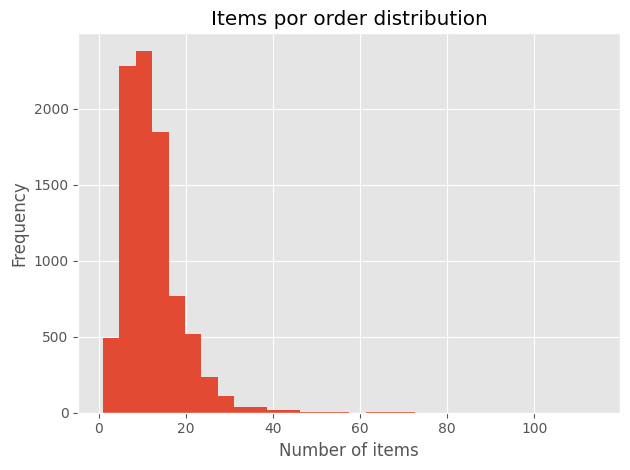

In [5]:
# Checking the "ordered_items" list column: empty lists, nulls, list lenght distribution
orders["n_items"] = orders["ordered_items"].apply(lambda x: len(x))
print("\nItems per order distribution:")
print(orders["n_items"].describe())
orders["n_items"].plot(kind="hist", bins=30, title="Items por order distribution")

plt.xlabel("Number of items")
plt.tight_layout()

In [6]:
print("--- inventory ---")
print("Shape: ", inventory.shape)
print("\nDtypes:")
print(inventory.dtypes)
print("\nMissing Values:")
print(inventory.isnull().sum())
inventory.head()
cols_to_check = [c for c in inventory.columns if c != "tags"]
print("\nDuplicates:", inventory.duplicated(subset=cols_to_check).sum())
print("\nNegative Prices:",(inventory["price"]<0).sum())
inventory.describe()

--- inventory ---
Shape:  (1733, 6)

Dtypes:
variant_id            int64
price               float64
compare_at_price    float64
vendor               object
product_type         object
tags                 object
dtype: object

Missing Values:
variant_id          0
price               0
compare_at_price    0
vendor              0
product_type        0
tags                0
dtype: int64

Duplicates: 0

Negative Prices: 0


,variant_id,price,compare_at_price
count,1.733000e+03,1733.000000,1733.000000
mean,3.694880e+13,6.307351,7.028881
std,2.725674e+12,7.107218,7.660542
min,3.361529e+13,0.000000,0.000000
25%,3.427657e+13,2.490000,2.850000
50%,3.927260e+13,3.990000,4.490000
75%,3.948318e+13,7.490000,8.210000
max,4.016793e+13,59.990000,60.000000


### Make the needed tables

In [7]:
# Take the 'ordered_items' column (which contains lists of product IDs)
# and expand each element of the list into its own row.
# This converts the dataset from one row per order
# to one row per individual item ordered.
order_items = orders.explode("ordered_items").rename(
    {"ordered_items": "variant_id"}, axis=1
)

In [8]:
order_items.head()

,id,user_id,created_at,order_date,user_order_seq,variant_id,n_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618849693828,14
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618860179588,14
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618874040452,14
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618907005060,14
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618907005060,14


In [9]:
order_items = order_items.merge(inventory, on="variant_id", how="left")

In [10]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107958 entries, 0 to 107957
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                107958 non-null  int64         
 1   user_id           107958 non-null  object        
 2   created_at        107958 non-null  datetime64[us]
 3   order_date        107958 non-null  datetime64[us]
 4   user_order_seq    107958 non-null  int64         
 5   variant_id        107958 non-null  object        
 6   n_items           107958 non-null  int64         
 7   price             92361 non-null   float64       
 8   compare_at_price  92361 non-null   float64       
 9   vendor            92361 non-null   object        
 10  product_type      92361 non-null   object        
 11  tags              92361 non-null   object        
dtypes: datetime64[us](2), float64(2), int64(3), object(5)
memory usage: 9.9+ MB


---
## H1: One-time buyers proportion

We want to understand how many users only placed a single order.
A high proportion could signal low retention or dissatisfaction.

In [11]:
# Count number of orders per user
orders_per_user = orders.groupby("user_id")["id"].nunique().reset_index()
orders_per_user.columns = ["user_id", "n_orders"]
orders_per_user.head()

,user_id,n_orders
0,0001d93f7e96bcb713aa8c5283258b5c3a80a7062fbcaf...,1
1,0011d59295eaf3ef5809aba64f2401f11e76f5bf602207...,1
2,002abde5718600d5d4cb567ff36deb2d6fb81460257769...,1
3,002b3799fded362f631b8238fa2a477a7673e1181b2756...,1
4,002fda98daf90c44ceb8601c93f504108afc2d3cdd5d00...,1


In [12]:
# Classify users
one_time_buyers = orders_per_user[orders_per_user["n_orders"] == 1]
repeat_buyers = orders_per_user[orders_per_user["n_orders"] > 1]

total_users = len(orders_per_user)
pct_one_time = len(one_time_buyers) / total_users
pct_repeat = len(repeat_buyers) / total_users

print(f"Total users: {total_users}")
print(f'One-time buyers: {len(one_time_buyers)} ({pct_one_time:.1%})')
print(f'Repeat buyers: {len(repeat_buyers)} ({pct_repeat:.1%})')

Total users: 4983
One-time buyers: 3572 (71.7%)
Repeat buyers: 1411 (28.3%)


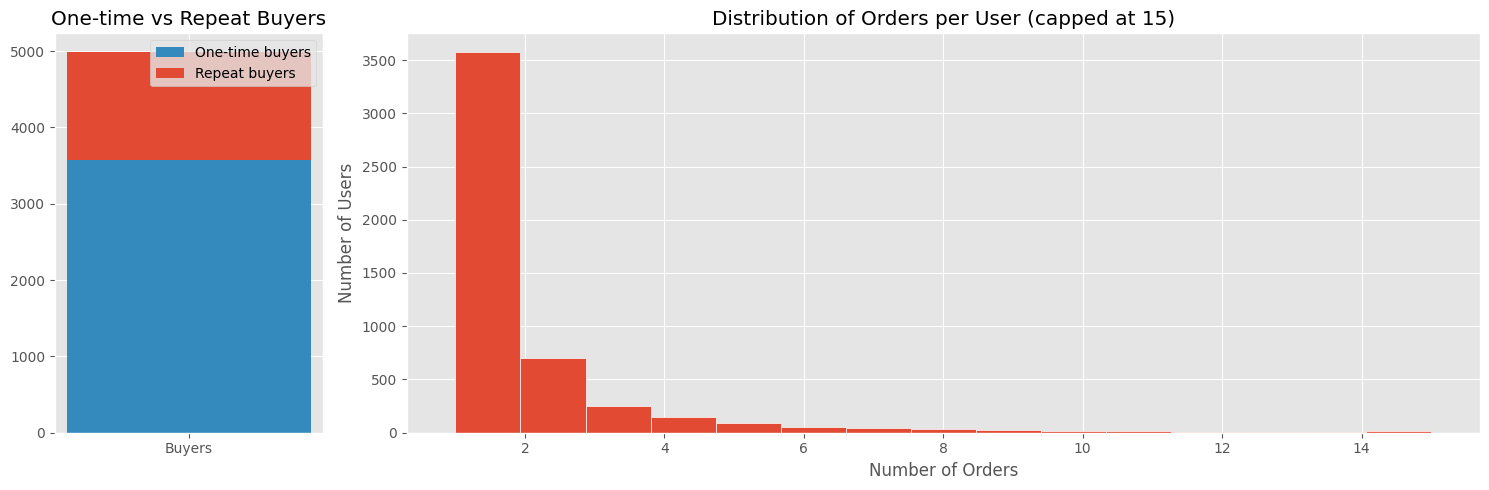

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 4]})

# Stacked bars
# Stacked bar chart
ax[0].bar(['Buyers'], [len(one_time_buyers)], label='One-time buyers', color='C1', width=0.3)
ax[0].bar(['Buyers'], [len(repeat_buyers)], bottom=[len(one_time_buyers)], label='Repeat buyers', color='C0', width=0.3)
ax[0].set_title('One-time vs Repeat Buyers')
ax[0].legend()

# Histogram of order frequency (capped at 15 for readability)
orders_per_user['n_orders'].clip(upper=15).hist(bins=15, ax=ax[1], color='C0', edgecolor='white')
ax[1].set_xlabel('Number of Orders')
ax[1].set_ylabel('Number of Users')
ax[1].set_title('Distribution of Orders per User (capped at 15)')

plt.tight_layout()
plt.show()


In [14]:
# Cross-check using user_order_seq - max_seq == 1 means only one order
max_seq_per_user = orders.groupby("user_id")["user_order_seq"].max().reset_index()
max_seq_per_user.columns = ["user_id", "max_seq_per_user"]

one_time_check = max_seq_per_user[max_seq_per_user["max_seq_per_user"] == 1]
print(f"One-time buyers (via user_order_seq): {len(one_time_check)} ({len(one_time_check) / len(max_seq_per_user):.1%})")

One-time buyers (via user_order_seq): 3572 (71.7%)


In [15]:
# Stats on repeat buyers
print(f"Repeat buyers - mean orders: {repeat_buyers.n_orders.mean():.2f}")
print(f"Repeat buyers - median orders: {repeat_buyers.n_orders.median():.2f}")
print(f"Repeat buyers - max orders: {repeat_buyers.n_orders.max()}")

Repeat buyers - mean orders: 3.69
Repeat buyers - median orders: 3.00
Repeat buyers - max orders: 25


### H1 Insights

> Key Insights:
> - We see that more than 70% of buyers are one-time buyers. 
> - Probably there is a retention issue, maybe there are problem with the service.
> - Our repeat buyers seem very satisfied as there prolonged recurrent orders.

---
# H2: Product Category Sales Distribution

We want to check if ~20% of categories account for ~80% of the total sales.

In [16]:
order_items.dropna().head()

,id,user_id,created_at,order_date,user_order_seq,variant_id,n_items,price,compare_at_price,vendor,product_type,tags
70,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,33667238658180,10,4.19,5.10,listerine,dental,[mouthwash]
71,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,33667238658180,10,4.19,5.10,listerine,dental,[mouthwash]
76,2217346236548,66a7b6a77952abc3ef3246da56fb148814704a3c2b420c...,2020-05-04 11:25:26,2020-05-04,1,33667206054020,8,17.99,20.65,ecover,delicates-stain-remover,"[cruelty-free, delicates-stain-remover, eco, v..."
77,2217346236548,66a7b6a77952abc3ef3246da56fb148814704a3c2b420c...,2020-05-04 11:25:26,2020-05-04,1,33667206283396,8,9.99,12.00,ecover,fabric-softener-freshener,"[cruelty-free, eco, fabric-softener-freshener,..."
81,2217346236548,66a7b6a77952abc3ef3246da56fb148814704a3c2b420c...,2020-05-04 11:25:26,2020-05-04,1,39459277602948,8,5.79,5.98,ecloth,cleaning-products,"[eco, sponges-cloths-gloves]"


In [17]:
missing = order_items["product_type"].isna().sum()
print(f"Number of items who couldn't be matched {missing} ({missing / len(order_items):.1%})")

Number of items who couldn't be matched 15597 (14.4%)


In [18]:
# Total sales by product type
sales_by_product_type = (order_items
                         .dropna(subset= ["product_type"])
                         .groupby("product_type")["price"]
                         .sum()
                         .sort_values(ascending=False)
                         .reset_index()
)

sales_by_product_type.columns = ["product_type", "total_sales"]

sales_by_product_type.head()

,product_type,total_sales
0,long-life-milk-substitutes,71736.70
1,cleaning-products,31948.04
2,toilet-roll-kitchen-roll-tissue,30270.66
3,tins-packaged-foods,28662.86
4,dishwashing,27163.98


In [19]:
# Cumulative percentage
sales_by_product_type["pct_sales"] = sales_by_product_type["total_sales"] / sales_by_product_type["total_sales"].sum()
sales_by_product_type["cumulative pct"] = sales_by_product_type["pct_sales"].cumsum()

sales_by_product_type.head(10)

,product_type,total_sales,pct_sales,cumulative pct
0,long-life-milk-substitutes,71736.70,0.146457,0.146457
1,cleaning-products,31948.04,0.065225,0.211681
2,toilet-roll-kitchen-roll-tissue,30270.66,0.061800,0.273481
3,tins-packaged-foods,28662.86,0.058518,0.331999
4,dishwashing,27163.98,0.055458,0.387456
5,washing-powder,22321.75,0.045572,0.433028
6,soft-drinks-mixers,22008.82,0.044933,0.477961
7,washing-liquid-gel,16389.18,0.033460,0.511421
8,snacks-confectionery,15958.63,0.032581,0.544002
9,fabric-softener-freshener,12867.07,0.026269,0.570271


In [20]:
# How many categories cover 80% of sales
n_categories_80 = (sales_by_product_type["cumulative pct"] <= 0.8).sum() + 1
total_categories = len(sales_by_product_type)

print(f"Total categories: {total_categories}")
print(f"Categories needed to reach 80% of sales: {n_categories_80} ({n_categories_80 / total_categories:.1%}) out of all categories.")

Total categories: 58
Categories needed to reach 80% of sales: 22 (37.9%) out of all categories.


In [21]:
print(sales_by_product_type.columns.tolist())

['product_type', 'total_sales', 'pct_sales', 'cumulative pct']


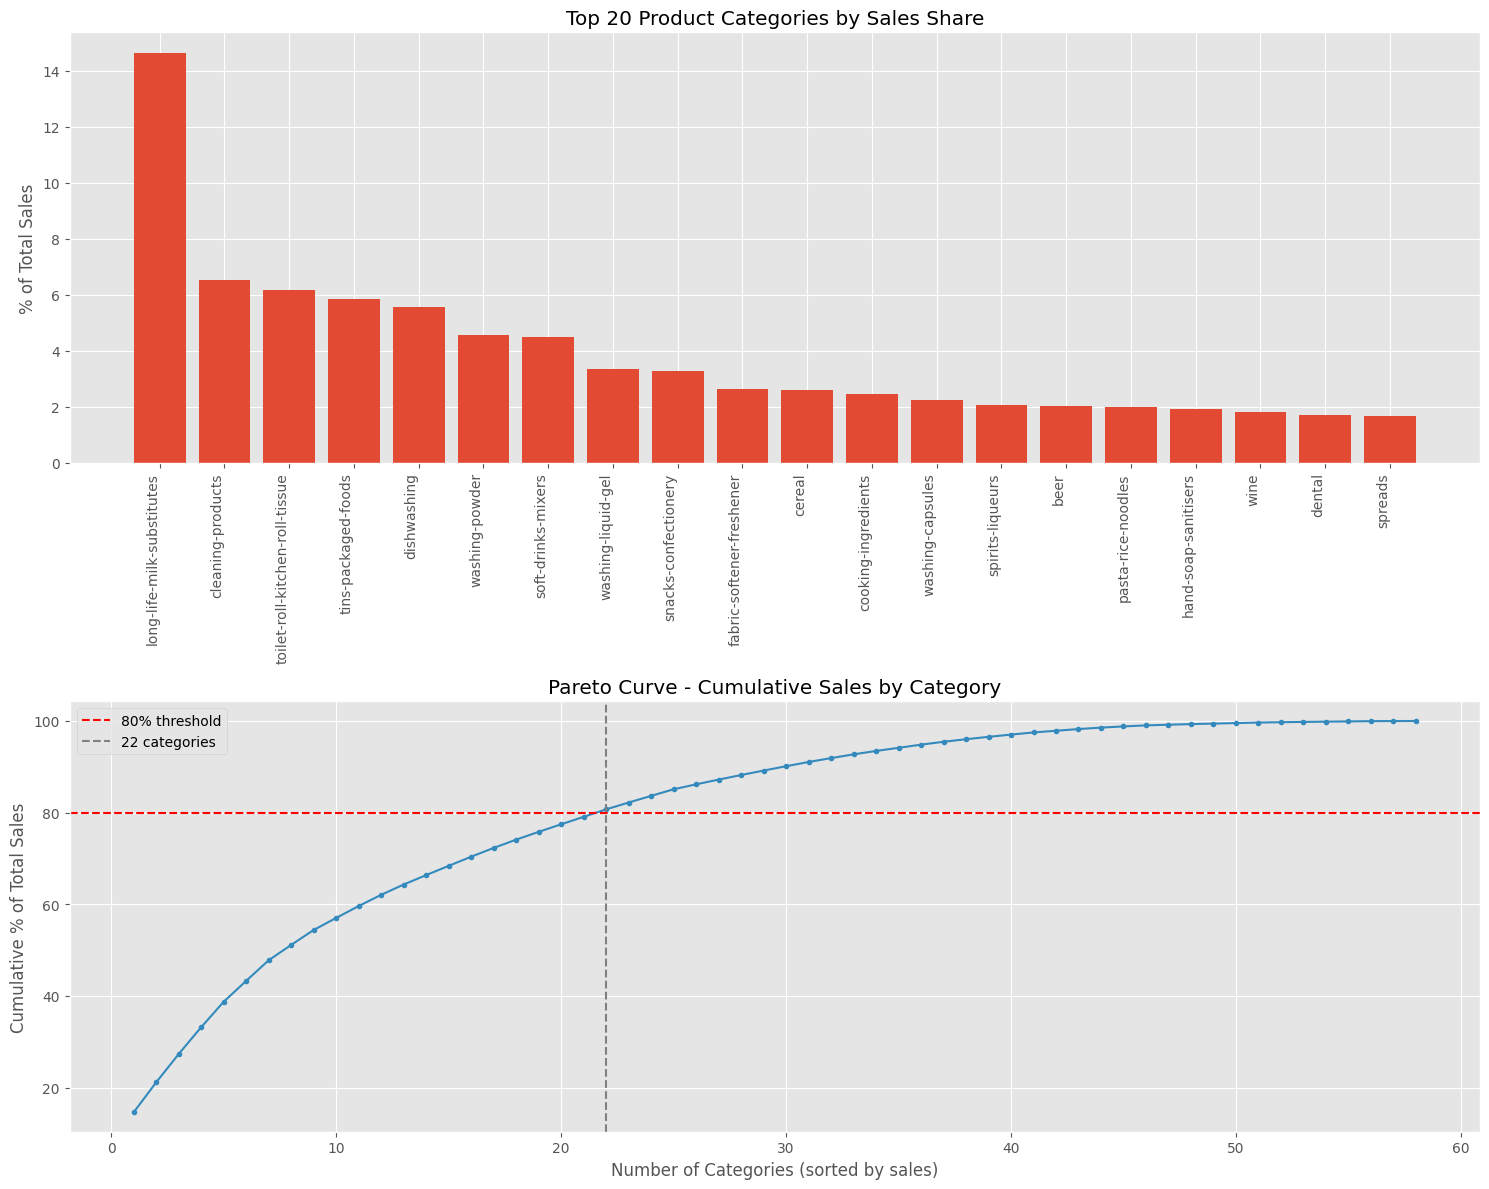

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(15, 12))

# Bar chart - top 20 categories by sales share
top_n = 20
top_categories = sales_by_product_type.head(top_n)

ax[0].bar(
    range(top_n),
    top_categories['pct_sales'] * 100,
    color='C0',
    tick_label=top_categories['product_type']
)
ax[0].set_xticklabels(top_categories['product_type'], rotation=90, ha='right')
ax[0].set_ylabel('% of Total Sales')
ax[0].set_title(f'Top {top_n} Product Categories by Sales Share')

ax[1].plot(range(1, len(sales_by_product_type) + 1), sales_by_product_type['cumulative pct'] * 100, color='C1', marker='.')
ax[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
ax[1].axvline(x=n_categories_80, color='gray', linestyle='--', label=f'{n_categories_80} categories')
ax[1].set_xlabel('Number of Categories (sorted by sales)')
ax[1].set_ylabel('Cumulative % of Total Sales')
ax[1].set_title('Pareto Curve - Cumulative Sales by Category')
ax[1].legend()

plt.tight_layout()
plt.show()

# H5 Insights

> **Key Insights**
> - **14.4% of items could not be matched to inventory.** This may indicate discontinued products or a snapshot of inventory at a specific point in time — a question worth clarifying with the client.
> - **Only 22 out of 58 product categories are needed to reach the 80% revenue threshold**, suggesting the distribution follows a roughly 80/40 Pareto curve rather than the classic 80/20 rule.
> - **Long-life milk substitutes stand out as a dominant category**, which may indicate a star product worth further investigation.

# Exploratory Data Analysis

In [23]:
feature_frame = pd.read_csv(f"{data_path}/feature_frame.csv")
ff = feature_frame
ff.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


- El dataset no tiene todos los productos de la tienda, solo los más vendidos. Los productos que casi nadie compra (que suelen ser muchísimos) no están incluidos.
- Este dataset solo incluye "repeating orders".
- La etiqueta "outcome" binaria es si el producto fue comprado o no en esa orden.
- Este dataset está pensado para entrenar un modelo que permita predecir que productos poner en la siguiente cesta antes de que llegue el usuario.

In [24]:
# Tamaño del dataset
ff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

In [25]:
# Missing values and duplicate rows
print(ff.isnull().sum())
print("\nDuplicates (full row):", ff.duplicated().sum())

variant_id                          0
product_type                        0
order_id                            0
user_id                             0
created_at                          0
order_date                          0
user_order_seq                      0
outcome                             0
ordered_before                      0
abandoned_before                    0
active_snoozed                      0
set_as_regular                      0
normalised_price                    0
discount_pct                        0
vendor                              0
global_popularity                   0
count_adults                        0
count_children                      0
count_babies                        0
count_pets                          0
people_ex_baby                      0
days_since_purchase_variant_id      0
avg_days_to_buy_variant_id          0
std_days_to_buy_variant_id          0
days_since_purchase_product_type    0
avg_days_to_buy_product_type        0
std_days_to_

In [26]:
# Arreglar fechas (están como object)
ff["created_at"] = pd.to_datetime(ff["created_at"])
ff["order_date"] = pd.to_datetime(ff["order_date"])

In [27]:
ff["outcome"].value_counts(normalize=True)

outcome
0.0    0.988463
1.0    0.011537
Name: proportion, dtype: float64

In [28]:
binary_cols = ['ordered_before', 'abandoned_before', 'active_snoozed', 'set_as_regular']
for col in binary_cols:
    rate = ff.groupby(col)['outcome'].mean().mul(100).round(2)
    print(f"\n{col}:\n{rate}")


ordered_before:
ordered_before
0.0     0.82
1.0    16.50
Name: outcome, dtype: float64

abandoned_before:
abandoned_before
0.0     1.11
1.0    71.79
Name: outcome, dtype: float64

active_snoozed:
active_snoozed
0.0     1.13
1.0    11.35
Name: outcome, dtype: float64

set_as_regular:
set_as_regular
0.0     1.07
1.0    24.97
Name: outcome, dtype: float64


# Insights:

ordered_before
- Without purchase history: 0.82% probability of buying
- With purchase history: 16.50%
If the user has already bought this product before, they are much more likely to buy it again.

abandoned_before
- If the product was not previously abandoned in the basket: 1.11% probability of buying
- If there was a previous basket abandonment: 71.79%
If a user added a product to their cart but didn't buy it, there is a very high chance they will end up buying it in the future. This feature looks very promising!

active_snoozed
- Not snoozed: 1.13%
- Snoozed: 11.35%

set_as_regular:
- Not set as regular: 1.07%
- Set as regular: 24.97%
Products marked as regular are purchased more frequently.

In [29]:
# We want to see how do the numeric features behave
num_cols = ["normalised_price", "discount_pct", "global_popularity", 
            "days_since_purchase_variant_id", "avg_days_to_buy_variant_id"]

pd.set_option("display.float_format", "{:.4f}".format)
ff[num_cols].describe()

,normalised_price,discount_pct,global_popularity,days_since_purchase_variant_id,avg_days_to_buy_variant_id
count,2880549.0000,2880549.0000,2880549.0000,2880549.0000,2880549.0000
mean,0.1273,0.1863,0.0107,33.1296,35.2373
std,0.1268,0.1934,0.0166,3.7072,10.5777
min,0.0160,-0.0402,0.0000,0.0000,0.0000
25%,0.0539,0.0846,0.0016,33.0000,30.0000
50%,0.0811,0.1169,0.0063,33.0000,34.0000
75%,0.1353,0.2235,0.0142,33.0000,40.0000
max,1.0000,1.3253,0.4254,148.0000,84.0000


# Numerical Features Insights

normalised_price
- Ranges from 0.016 to 1.0 (normalised, 1 = most expensive)
- Mean of 0.127 → most products are relatively cheap
- No issues found

discount_pct
- Mean discount of 18.6%
- Minimum of -0.04 → negative discount, data error
- Maximum of 1.325 → 132% discount, impossible value
- Needs cleaning

global_popularity
- Ranges from 0 to 0.425, mean of 0.0107
- Very skewed distribution → a few products concentrate most of the popularity
- No issues found

days_since_purchase_variant_id
- 25th, 50th and 75th percentile are all exactly 33 → suspicious, likely a default value when no purchase history exists
- Needs further investigation

avg_days_to_buy_variant_id
- Mean of 35 days → users repurchase approximately once a month
- Reasonable range of 0 to 84 days

In [30]:
# We need to fix errors in discount_pct
total = len(ff)

neg = (ff['discount_pct'] < 0).sum()
over_one = (ff['discount_pct'] > 1).sum()

print("Negative discounts:", neg, f"({neg/total*100:.2f}%)")
print("Discounts > 1:", over_one, f"({over_one/total*100:.2f}%)")

Negative discounts: 1587 (0.06%)
Discounts > 1: 58582 (2.03%)


- Negative discounts (0.06%) are likely due to a pricing calculation error 
  or data entry mistake. Given the negligible volume, we clip them to 0.
- Discounts > 1 (2.03%) are capped to 1.0 as they likely reflect 
  miscalculations rather than real promotions.

In [40]:
# Cap discount_pct to valid range [0, 1]
ff['discount_pct'] = ff['discount_pct'].clip(lower=0, upper=1)

# Verify the fix
print("Min discount:", ff['discount_pct'].min())
print("Max discount:", ff['discount_pct'].max())

Min discount: 0.0
Max discount: 1.0


In [ ]:
# days_since_purchase_variant_id has some strange values, maybe 33 is assigned as a placeholder
ff['days_since_purchase_variant_id'].value_counts().head(10)

days_since_purchase_variant_id
33.0000    2836211
14.0000       1022
29.0000       1016
21.0000        997
30.0000        983
27.0000        951
19.0000        904
20.0000        900
22.0000        900
15.0000        858
Name: count, dtype: int64

In [35]:
# When days=33, has the user ordered before?
mask_33 = ff['days_since_purchase_variant_id'] == 33
print("ordered_before distribution when days=33:")
print(ff[mask_33]['ordered_before'].value_counts(normalize=True).round(4))

ordered_before distribution when days=33:
ordered_before
0.0000   0.9942
1.0000   0.0058
Name: proportion, dtype: float64


We observe that 99.42% of rows where days_since_purchase_variant_id == 33 correspond to users who have never ordered that product before. This strongly suggests that 33 is a default placeholder value assigned by the system when no purchase history exists.

/tmp/ipykernel_2143/3919808529.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ff.groupby("discount_bucket")["outcome"].mean().plot(kind="bar")


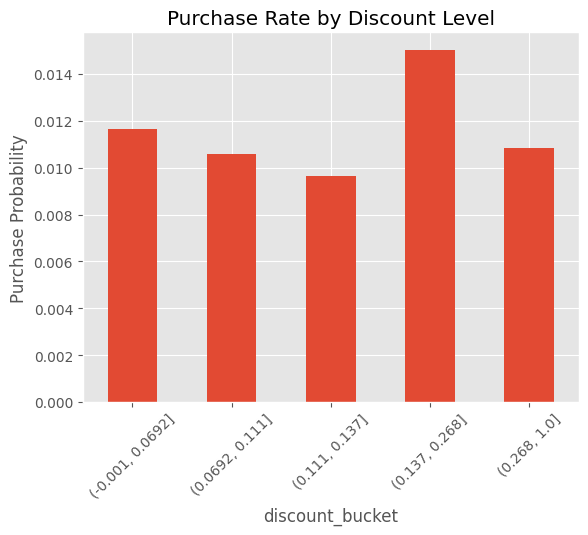

In [41]:
ff["discount_bucket"] = pd.qcut(ff["discount_pct"], 5)

ff.groupby("discount_bucket")["outcome"].mean().plot(kind="bar")
plt.title("Purchase Rate by Discount Level")
plt.ylabel("Purchase Probability")
plt.xticks(rotation=45)
plt.show()

Higher discounts slightly increase purchase probability.

Effect is moderate and not perfectly consistent.

Discount helps, but it’s not a major driver.

/tmp/ipykernel_2143/2067164662.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ff.groupby("price_bucket")["outcome"].mean().plot(kind="bar")


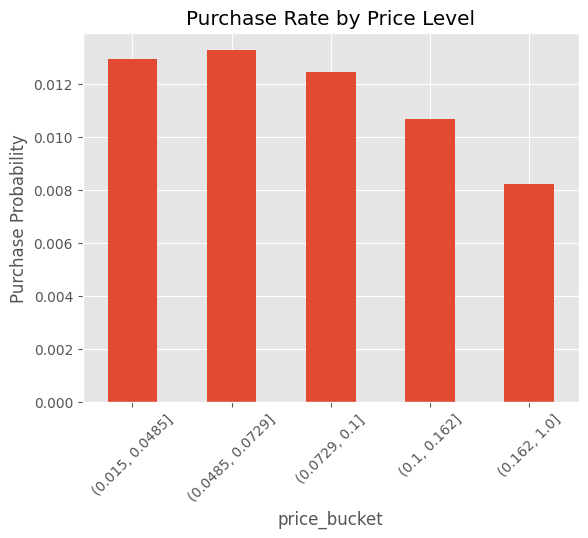

In [42]:
ff["price_bucket"] = pd.qcut(ff["normalised_price"], 5)

ff.groupby("price_bucket")["outcome"].mean().plot(kind="bar")
plt.title("Purchase Rate by Price Level")
plt.ylabel("Purchase Probability")
plt.xticks(rotation=45)
plt.show()

Clear negative relationship.

Cheaper products are more likely to be purchased.

Stronger effect than discount.

/tmp/ipykernel_2143/1440429045.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ff.groupby("pop_bucket")["outcome"].mean().plot(kind="bar")


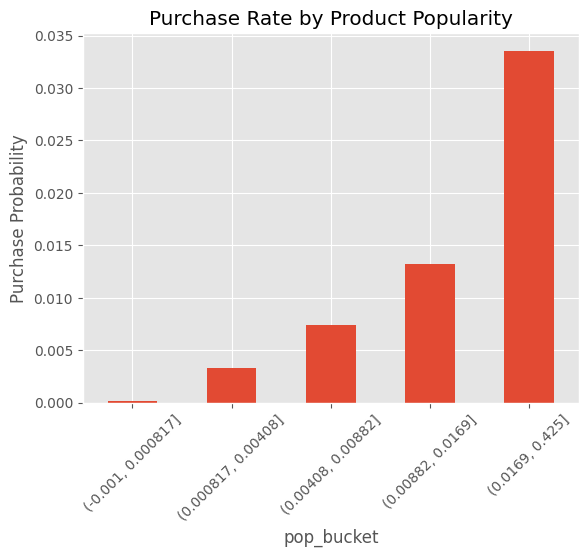

In [43]:
ff["pop_bucket"] = pd.qcut(ff["global_popularity"], 5)

ff.groupby("pop_bucket")["outcome"].mean().plot(kind="bar")
plt.title("Purchase Rate by Product Popularity")
plt.ylabel("Purchase Probability")
plt.xticks(rotation=45)
plt.show()

Very strong positive relationship.

Highly popular products are much more likely to be purchased.

Strongest commercial signal among the three.